# Where do our models disagree?

This review compares **16 retained current model/blend forecasts**, using the same saved current evidence. Five core models summarize genuinely different approaches: final/older Gaussian, their corresponding Student versions, and corrected polling. The mixtures and mean-shift blends remain visible, but are not counted as independent votes.

No downloads or model fitting occur here. Run notebook04 before this notebook if current evidence changes. Current2026 outcomes are unknown; disagreement is not proof of error. The largest *numerical margin* differences can occur in safe states, while smaller differences can matter more for control.

Auxiliary interval fields in older helper/blend exports were stale. Gaussian rescoring now refreshes all intervals and scores. The latest live rerun preserves margins, probabilities,70% intervals and seats exactly; this review derives widths directly from interval endpoints.

In [2]:
from pathlib import Path
import sys,json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0,str(ROOT))
import election_lab as lab
from model_labels import display, model_label
import model_disagreement_review as review
pd.set_option('display.max_rows',40)
RUN=review.run()
t={name:pd.read_parquet(RUN/(name+'.parquet')) for name in ['predictions','seats','state_ranges','pair_summary','pair_states','dependencies','historical_summary']}
meta=json.loads((RUN/'run.json').read_text())
print('As of',meta['as_of'],'| saved comparison:',RUN.relative_to(ROOT))
print('Data sources:',meta['sources'])


As of 2026-09-21 | saved comparison: cache/runs/model_disagreement/20260921T190059.014593Z
Data sources: {'cache/runs/live/20260921T185745.202426Z': 'f4ee18e438566a0234719d12dd2e487cd045dbe3c34a6a7388c565aa3ab12935', 'cache/runs/portfolio/20260921T185943.532983Z': 'e28481edc9f4636c51512564464c6028789a512082bacbbcb119d163a9c4960f'}


## 1. Chamber forecasts and dependence

Point D seats count positive predicted means; expected seats sum state win probabilities. D control requires51. The corrected-polling helper's own chamber calculation assumes independent states; the Bayesian/mixture forecasts use joint state distributions. Do not attribute a chamber difference solely to a mean difference.

The dependency table describes the saved joint covariance and seat draws. Tail events (55+ or45− D seats) differ from central70% intervals. A higher average correlation is not automatically better; it changes how often races move together.

In [3]:
core_seats=t['seats'].set_index('model').reindex(review.DISPLAY).reset_index()
display(core_seats[['model','point_D','point_R','expected_D','D_control_pct','D_lo70','D_hi70']].round(3))
d=t['dependencies'];display(d[d.model.isin(review.DISPLAY)].round(4))
print('All retained models and blends')
display(t['seats'][['model','expected_D','D_control_pct','D_lo70','D_hi70']].round(3))


,model,point_D,point_R,expected_D,D_control_pct,D_lo70,D_hi70
0,Gaussian Bayesian,51,49,50.320,45.520,49,52
1,Matched Student-t (df5),51,49,50.476,50.028,49,52
2,Older Gaussian,50,50,51.090,61.997,49,53
3,Student-t research helper,50,50,51.115,63.006,49,53
4,Non-Bayesian corrected,48,52,48.373,16.354,46,51
5,Four-model mixture,50,50,50.748,55.138,49,53
6,Mixture + polling 20%,50,50,50.419,47.381,49,52


,model,mean_state_correlation,min_state_correlation,max_state_correlation,seat_sd,p_D_at_least_55,p_D_45_or_fewer,p_tie50
0,Gaussian Bayesian,0.0286,-0.0480,0.0920,1.5526,0.0022,0.0010,0.2509
1,Older Gaussian,0.0178,0.0004,0.1499,2.0459,0.0446,0.0032,0.1651
2,Student-t research helper,0.0172,-0.0196,0.1387,1.8968,0.0365,0.0015,0.1757
3,Matched Student-t (df5),0.0266,-0.0418,0.0876,1.4323,0.0020,0.0004,0.2610
4,Four-model mixture,0.0198,-0.1486,0.1076,1.7863,0.0213,0.0015,0.2132
7,Mixture + polling 20%,0.0198,-0.1486,0.1076,1.8294,0.0153,0.0035,0.2231


All retained models and blends


,model,expected_D,D_control_pct,D_lo70,D_hi70
0,Gaussian Bayesian,50.320,45.520,49,52
1,Corrected 10%,50.179,41.807,49,52
2,Corrected 20%,50.031,38.290,48,52
3,Corrected 40%,49.710,31.993,48,51
4,Corrected 50%,49.539,28.950,48,51
5,Non-Bayesian corrected,48.373,16.354,46,51
6,Older Gaussian,51.090,61.997,49,53
7,Student-t research helper,51.115,63.006,49,53
8,Matched Student-t (df5),50.476,50.028,49,52
9,Four-model mixture,50.748,55.138,49,53


## 2. Rank state disagreements

The five-core-model range includes the non-Bayesian helper; the four-Bayesian range isolates prior/architecture/tail changes. A probability spread is measured in percentage points. `reference_poll_pp` is the admitted raw polling aggregate; NaN means no admitted poll, not necessarily no poll ever published.

The tables identify the endpoint models instead of treating all experimental variants as equal independent evidence. Point-call disagreement merely means a mean crossed zero; inspect its size and probability too.

In [4]:
ranges=t['state_ranges']
for scope in ['five core','four Bayesian']:
    top=ranges[ranges.scope.eq(scope)].sort_values('prob_spread',ascending=False).head(12).copy()
    top['prob_min_pct']=100*top.prob_min;top['prob_max_pct']=100*top.prob_max;top['prob_spread_pct']=100*top.prob_spread
    print(scope,'largest probability disagreements')
    display(top[['geography','reference_poll_pp','admitted_poll','margin_min','margin_max','prob_min_pct','prob_max_pct','prob_spread_pct','prob_min_model','prob_max_model']].round(2))
print('Largest numerical margin ranges, five core models')
display(ranges[ranges.scope.eq('five core')].sort_values('margin_spread',ascending=False).head(10)[['geography','reference_poll_pp','margin_min','margin_max','margin_spread','margin_min_model','margin_max_model']].round(2))


five core largest probability disagreements


,geography,reference_poll_pp,admitted_poll,margin_min,margin_max,prob_min_pct,prob_max_pct,prob_spread_pct,prob_min_model,prob_max_model
15,MI,2.48,True,-3.86,4.99,37.93,85.01,47.08,Non-Bayesian corrected,Matched Student-t (df5)
14,ME,3.35,True,-0.04,8.19,49.88,93.99,44.11,Non-Bayesian corrected,Matched Student-t (df5)
17,MS,-6.00,True,-11.64,-3.45,2.06,39.18,37.12,Matched Student-t (df5),Non-Bayesian corrected
24,OH,4.32,True,-2.74,2.90,41.35,74.20,32.85,Non-Bayesian corrected,Matched Student-t (df5)
10,KS,-1.29,True,-8.39,-4.24,6.37,36.78,30.41,Gaussian Bayesian,Non-Bayesian corrected
33,WV,NaN,False,-32.47,-11.71,4.77,33.03,28.26,Matched Student-t (df5),Older Gaussian
16,MN,3.67,True,4.68,9.16,64.54,92.67,28.13,Non-Bayesian corrected,Student-t research helper
32,VA,NaN,False,6.90,16.63,70.89,98.41,27.52,Non-Bayesian corrected,Gaussian Bayesian
3,CO,NaN,False,5.95,17.62,68.24,94.28,26.04,Non-Bayesian corrected,Matched Student-t (df5)
6,GA,6.78,True,3.39,5.94,60.66,86.39,25.73,Non-Bayesian corrected,Matched Student-t (df5)


four Bayesian largest probability disagreements


,geography,reference_poll_pp,admitted_poll,margin_min,margin_max,prob_min_pct,prob_max_pct,prob_spread_pct,prob_min_model,prob_max_model
68,WV,NaN,False,-32.47,-18.99,4.77,33.03,28.26,Matched Student-t (df5),Older Gaussian
56,NH,1.79,True,4.65,9.98,74.11,95.41,21.30,Older Gaussian,Gaussian Bayesian
55,NE,NaN,False,-24.08,-20.90,3.39,22.52,19.13,Matched Student-t (df5),Older Gaussian
35,AK,1.21,True,-3.10,-0.77,27.48,45.90,18.42,Matched Student-t (df5),Older Gaussian
49,ME,3.35,True,5.20,8.19,76.24,93.99,17.75,Older Gaussian,Matched Student-t (df5)
40,FL,-2.91,True,-5.48,-4.14,15.10,31.83,16.73,Matched Student-t (df5),Older Gaussian
37,AR,-6.12,True,-20.80,-11.70,0.17,14.36,14.20,Gaussian Bayesian,Older Gaussian
64,SD,NaN,False,-34.05,-27.73,0.02,13.98,13.96,Gaussian Bayesian,Older Gaussian
47,LA,NaN,False,-16.72,-15.79,2.71,14.88,12.17,Gaussian Bayesian,Older Gaussian
59,OH,4.32,True,2.11,2.90,63.12,74.20,11.07,Older Gaussian,Matched Student-t (df5)


Largest numerical margin ranges, five core models


,geography,reference_poll_pp,margin_min,margin_max,margin_spread,margin_min_model,margin_max_model
33,WV,NaN,-32.47,-11.71,20.75,Gaussian Bayesian,Non-Bayesian corrected
26,OR,NaN,8.38,23.18,14.80,Non-Bayesian corrected,Matched Student-t (df5)
3,CO,NaN,5.95,17.62,11.67,Non-Bayesian corrected,Matched Student-t (df5)
2,AR,-6.12,-23.32,-11.70,11.62,Non-Bayesian corrected,Student-t research helper
27,RI,17.19,16.62,27.72,11.10,Non-Bayesian corrected,Matched Student-t (df5)
4,DE,NaN,15.52,25.88,10.36,Non-Bayesian corrected,Student-t research helper
13,MA,20.72,15.77,25.66,9.89,Non-Bayesian corrected,Matched Student-t (df5)
11,KY,-9.01,-21.11,-11.35,9.76,Non-Bayesian corrected,Student-t research helper
32,VA,NaN,6.90,16.63,9.73,Non-Bayesian corrected,Matched Student-t (df5)
18,MT,-21.54,-28.30,-18.69,9.61,Non-Bayesian corrected,Gaussian Bayesian


## 3. Margins, probabilities and intervals together

Points are posterior/predictive **means**; lines are central70% intervals. The vertical line is a tie. Different panels have different scales. No admitted polls in WV/NE means their wide intervals largely express historical assumptions and interstate inference.

Student distributions here are variance-standardized before conditioning. Heavier far tails can coexist with narrower central intervals. Compare both70% and95% widths; neither alone fully describes extreme-tail risk. Margin approximations are unbounded: an interval extending outside±100 pp exposes a model limitation, not a possible vote share.

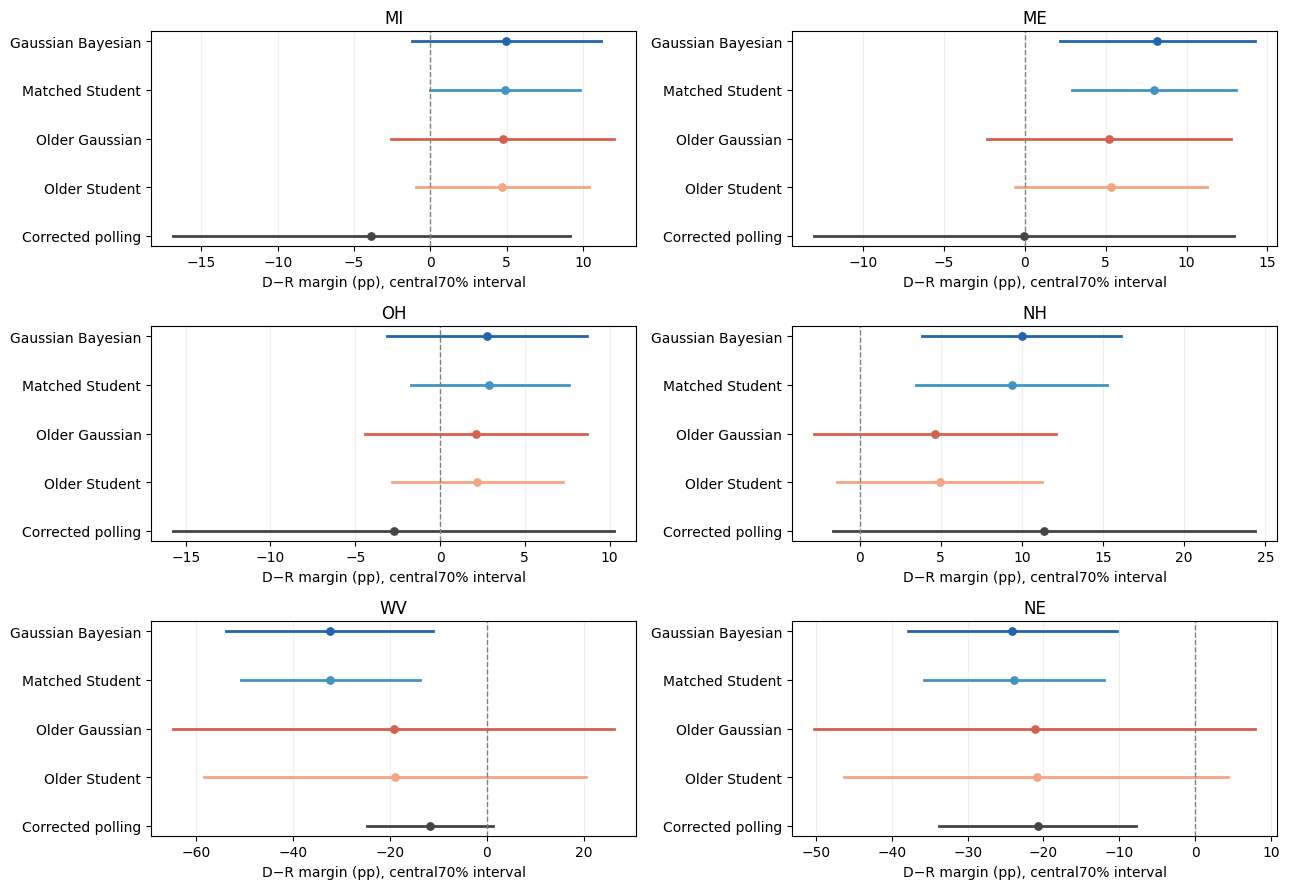

Widest uncertainty disagreements


,geography,width70_min,width70_max,width95_min,width95_max,width70_min_model,width70_max_model
33,WV,26.00,90.91,49.17,174.68,Non-Bayesian corrected,Older Gaussian
29,SD,17.32,53.69,37.58,102.64,Matched Student-t (df5),Older Gaussian
20,NE,23.84,58.15,49.17,112.89,Matched Student-t (df5),Older Gaussian
19,NC,7.31,26.00,14.31,49.17,Student-t research helper,Non-Bayesian corrected
12,LA,15.02,33.28,32.55,64.55,Matched Student-t (df5),Older Gaussian
31,TX,8.27,26.00,15.95,49.17,Matched Student-t (df5),Non-Bayesian corrected
24,OH,9.33,26.00,18.13,49.17,Matched Student-t (df5),Non-Bayesian corrected
7,IA,9.79,26.00,19.20,49.17,Matched Student-t (df5),Non-Bayesian corrected
15,MI,9.83,26.00,19.29,49.17,Matched Student-t (df5),Non-Bayesian corrected
6,GA,10.01,26.00,19.57,49.17,Matched Student-t (df5),Non-Bayesian corrected


Central95% intervals crossing physical margin bounds


,geography,model,lo95_pp,hi95_pp
243,WV,Older Gaussian,-105.22,66.70
278,WV,Student-t research helper,-106.49,68.18


In [5]:
p=t['predictions'];core=p[p.model.isin(review.CORE)]
fig,axes=plt.subplots(3,2,figsize=(13,9))
short=['Gaussian Bayesian','Matched Student','Older Gaussian','Older Student','Corrected polling']
colors=['#2166ac','#4393c3','#d6604d','#f4a582','#444444']
for ax,state in zip(axes.flat,['MI','ME','OH','NH','WV','NE']):
    g=core[core.geography.eq(state)].set_index('model').reindex(review.CORE)
    for i,row in enumerate(g.itertuples()):
        ax.plot([row.lo70_pp,row.hi70_pp],[i,i],color=colors[i],lw=2)
        ax.scatter(row.margin_pp,i,color=colors[i],s=28,zorder=3)
    ax.axvline(0,color='grey',ls='--',lw=1);ax.set_yticks(range(5),short);ax.invert_yaxis()
    ax.set(title=state,xlabel='D−R margin (pp), central70% interval');ax.grid(axis='x',alpha=.2)
fig.tight_layout();plt.show()
print('Widest uncertainty disagreements')
display(ranges[ranges.scope.eq('five core')].sort_values('width70_spread',ascending=False).head(10)[['geography','width70_min','width70_max','width95_min','width95_max','width70_min_model','width70_max_model']].round(2))
print('Central95% intervals crossing physical margin bounds')
display(p[p.model.isin(review.CORE)&p.central95_crosses_physical_bounds][['geography','model','lo95_pp','hi95_pp']].round(2))


## 4. Decompose differences between model families

The pair table compares each right-hand model with its left-hand reference. Splitting expected-seat differences by poll availability helps determine whether polling or prior assumptions deserve closer inspection. This is arithmetic attribution, not a causal decomposition: several architecture ingredients change together between older and final models.

A same-mean prediction can have very different P(D) if its uncertainty differs. Conversely, tiny mean changes can flip a near-zero point call without indicating a meaningful probability disagreement.

In [6]:
display(t['pair_summary'].round(4))
print('All states: D−R margins')
display(p[p.model.isin(review.DISPLAY)].pivot(index=['geography','special'],columns='model',values='margin_pp').reindex(columns=review.DISPLAY).round(2))
print('All states: D win probability (%)')
display(p[p.model.isin(review.DISPLAY)].pivot(index=['geography','special'],columns='model',values='D_probability_pct').reindex(columns=review.DISPLAY).round(1))


,left,right,mean_abs_margin_difference_pp,max_abs_margin_difference_pp,mean_abs_probability_difference_pct,mean_width70_change_pp,mean_width95_change_pp,expected_D_change,unpolled_expected_D_change,polled_expected_D_change
0,Gaussian Bayesian,Older Gaussian,2.1577,13.2059,6.7479,6.9551,13.1525,0.7701,0.6141,0.1560
1,Gaussian Bayesian,Matched Student-t (df5),0.2412,1.5673,1.4251,-2.1899,-1.5516,0.1561,0.0028,0.1532
2,Older Gaussian,Student-t research helper,0.2437,1.2876,2.4653,-3.3824,-2.3749,0.0246,-0.0723,0.0969
3,Gaussian Bayesian,Non-Bayesian corrected,5.7801,20.7534,13.3926,10.3420,19.5574,-1.9476,-0.8909,-1.0567
4,Gaussian Bayesian,Four-model mixture,1.0967,6.6880,2.7896,1.9897,7.6676,0.4271,0.2876,0.1395
5,Four-model mixture,Mixture + polling 20%,1.1075,2.8411,1.6056,0.0000,0.0000,-0.3290,-0.0417,-0.2874


All states: D−R margins


,model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
geography,special,,,,,,,
AK,False,-3.10,-2.87,-0.77,-0.86,-2.17,-1.90,-1.95
AL,False,-22.02,-21.94,-18.24,-18.62,-21.69,-20.21,-20.50
AR,False,-20.80,-19.23,-12.03,-11.70,-23.32,-15.94,-17.42
CO,False,17.44,17.62,14.13,14.40,5.95,15.90,13.91
DE,False,24.95,25.15,25.61,25.88,15.52,25.40,23.42
FL,True,-5.48,-5.32,-4.16,-4.14,-9.12,-4.78,-5.65
GA,False,5.22,5.31,5.94,5.90,3.39,5.59,5.15
IA,False,-3.27,-3.08,-2.80,-2.80,-5.46,-2.99,-3.48
ID,False,-25.97,-25.75,-27.04,-26.77,-29.76,-26.38,-27.06


All states: D win probability (%)


,model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
geography,special,,,,,,,
AK,False,30.0,27.5,45.9,44.3,43.1,37.0,36.7
AL,False,0.0,0.1,3.3,1.9,4.2,1.3,1.2
AR,False,0.2,0.8,14.4,9.5,3.1,6.3,4.8
CO,False,92.7,94.3,85.5,88.8,68.2,90.3,87.5
DE,False,99.9,99.6,99.3,98.9,89.2,99.4,99.2
FL,True,20.3,15.1,31.8,26.7,23.3,23.7,20.0
GA,False,80.8,86.4,78.3,83.6,60.7,82.1,80.1
IA,False,29.2,25.8,34.0,29.6,33.2,29.4,26.5
ID,False,0.0,0.3,0.1,0.5,0.9,0.2,0.2


## 5. Historical context and interpretation

Historical2016–2024 accuracy/MAE/Brier/coverage help assess a model's previous behavior, but do not establish which2026 forecast is right. These years were reused during architecture exploration. Older models can have higher expected D seats despite fewer positive-mean calls because broad uncertainty gives low-probability upsets in Republican states.

Raw polling is a reference column, not an additional independent calibrated model. Every retained model and blend appears in saved detail tables. The corrected-polling helper uses a pooled marginal SD, unlike the state-specific Bayesian uncertainties. Models/variants share data, so a range across them is not a confidence interval and majority voting among variants is not justified.

In [7]:
h=t['historical_summary']
display(h[h.first_cycle.eq(2016)&h.model.isin(review.DISPLAY)][['scenario','model','correct','n','absolute_error_pp','brier','coverage70','width70_pp']].round(3))
lab.verify_run(RUN)
assert not p.duplicated(['target_id','model']).any()
assert p.p_dem.between(0,1).all()
assert (p.lo95_pp<=p.lo70_pp).all() and (p.hi95_pp>=p.hi70_pp).all()
print(len(p.model.unique()),'forecasts ×',p.target_id.nunique(),'contests; intervals and manifest verified.')


,scenario,model,correct,n,absolute_error_pp,brier,coverage70,width70_pp
24,matched_live,Gaussian Bayesian,128,140,6.307,0.055,78.571,19.876
25,matched_live,Four-model mixture,129,140,6.512,0.056,75.000,18.871
26,matched_live,Matched Student-t (df5),129,140,6.344,0.055,66.429,16.929
28,matched_live,Mixture + polling 20%,129,140,6.512,0.057,75.714,18.871
33,matched_live,Non-Bayesian corrected,127,140,7.472,0.078,90.090,28.406
34,matched_live,Older Gaussian,129,140,6.808,0.059,79.286,20.897
35,matched_live,Student-t research helper,129,140,6.801,0.058,66.429,17.751
36,oct31,Gaussian Bayesian,132,140,5.206,0.050,73.571,15.800
37,oct31,Four-model mixture,132,140,5.275,0.050,67.143,14.419
38,oct31,Matched Student-t (df5),132,140,5.224,0.049,62.143,13.287


16 forecasts × 35 contests; intervals and manifest verified.


## Saved reports

[Read the published report](../outputs/reports/experiments/model_disagreement.md) · [All outputs and dated reports](../outputs/README.md)
